# Projeto Big Data — Fases 2 e 3: Exploração, Transformação, Treino e Avaliação
## Mestrado em ADSAD | Docente: Ricardo Malheiro | Ano Letivo 2025-2026

**Dataset:** USA Housing Listings (Craigslist) — [Kaggle](https://www.kaggle.com/datasets/austinreese/usa-housing-listings)  
**Problema:** Regressão — prever o **preço de arrendamento** (`price`) com base nas características dos imóveis.

---
### Estrutura do Notebook
**Fase 2 — Exploração e Transformação**
1. Configuração do ambiente
2. Carregamento do dataset
3. Análise exploratória
4. Tratamento de valores ausentes
5. Remoção de colunas irrelevantes
6. Tratamento de outliers
7. Codificação de variáveis categóricas
8. Normalização / Padronização de variáveis numéricas
9. Visualizações
10. Preparação final do dataset para ML

**Fase 3 — Treino e Avaliação**
11. Divisão treino / teste
12. Modelo 1 — Regressão Linear
13. Modelo 2 — Random Forest
14. Modelo 3 — Gradient Boosted Trees (GBT)
15. Comparação dos modelos
16. Gráficos de avaliação
17. Importância das features
18. Métrica complementar — MAPE
19. Exemplos de previsões
20. Cross-Validation com Grid Search
21. Resumo final e conclusões
22. Encerrar sessão Spark

## 1. Configuração do Ambiente

In [34]:
# Instalar as dependências necessárias
!pip install pyspark findspark kagglehub matplotlib seaborn

In [35]:
import findspark
findspark.init()

In [36]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master('local[*]') \
    .appName('Fase2_HousingListings') \
    .config('spark.driver.bindAddress', '127.0.0.1') \
    .getOrCreate()

print('Sessão Spark iniciada! Versão:', spark.version)

Sessão Spark iniciada! Versão: 4.0.2


## 2. Carregamento do Dataset

O dataset contém listagens de imóveis do Craigslist em todo os EUA.  
**Nota importante:** carregamos tudo como STRING (`inferSchema=False`) e fazemos a conversão
de tipos manualmente com `TRY_CAST` — desta forma valores inválidos tornam-se `null`
em vez de lançar excepção.

In [37]:
import kagglehub

path = kagglehub.dataset_download('austinreese/usa-housing-listings')
print('Localização dos ficheiros:', path)

Using Colab cache for faster access to the 'usa-housing-listings' dataset.
Localização dos ficheiros: /kaggle/input/usa-housing-listings


In [38]:
import os
for f in os.listdir(path):
    print(f)

housing.csv


In [ ]:
# inferSchema=False → carrega TUDO como STRING
# Assim evitamos que o Spark infira tipos errados e garante que TRY_CAST
# converte valores inválidos em null em vez de lançar excepção
csv_file = os.path.join(path, "housing.csv")

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("HousingListings") \
    .getOrCreate()

df = spark.read.csv(
    csv_file,
    header=True,
    inferSchema=False,  
    multiLine=True,     
    escape='"'          
)

print(f"Total de registos : {df.count():,}")
print(f"Total de colunas  : {len(df.columns)}")
print(f"Colunas           : {df.columns}")

Total de registos : 384,977
Total de colunas  : 22
Colunas           : ['id', 'url', 'region', 'region_url', 'price', 'type', 'sqfeet', 'beds', 'baths', 'cats_allowed', 'dogs_allowed', 'smoking_allowed', 'wheelchair_access', 'electric_vehicle_charge', 'comes_furnished', 'laundry_options', 'parking_options', 'image_url', 'description', 'lat', 'long', 'state']


In [40]:
# Converter colunas numéricas usando TRY_CAST )
# TRY_CAST devolve NULL para valores inválidos em vez de lançar excepção
# É a solução oficial recomendada pelo próprio erro do Spark
from pyspark.sql.functions import expr

colunas_numericas = ['price', 'sqfeet', 'beds', 'baths', 'lat', 'long']

for c in colunas_numericas:
    df = df.withColumn(c, expr(f'TRY_CAST(`{c}` AS DOUBLE)'))

print('Tipos após TRY_CAST:')
df.select(colunas_numericas).printSchema()

Tipos após TRY_CAST:
root
 |-- price: double (nullable = true)
 |-- sqfeet: double (nullable = true)
 |-- beds: double (nullable = true)
 |-- baths: double (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)



## 3. Análise Exploratória

### 3.1 Estrutura do Dataset

In [41]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- url: string (nullable = true)
 |-- region: string (nullable = true)
 |-- region_url: string (nullable = true)
 |-- price: double (nullable = true)
 |-- type: string (nullable = true)
 |-- sqfeet: double (nullable = true)
 |-- beds: double (nullable = true)
 |-- baths: double (nullable = true)
 |-- cats_allowed: string (nullable = true)
 |-- dogs_allowed: string (nullable = true)
 |-- smoking_allowed: string (nullable = true)
 |-- wheelchair_access: string (nullable = true)
 |-- electric_vehicle_charge: string (nullable = true)
 |-- comes_furnished: string (nullable = true)
 |-- laundry_options: string (nullable = true)
 |-- parking_options: string (nullable = true)
 |-- image_url: string (nullable = true)
 |-- description: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- state: string (nullable = true)



In [42]:
df.show(5, truncate=True)

+----------+--------------------+------------+--------------------+------+---------+------+----+-----+------------+------------+---------------+-----------------+-----------------------+---------------+---------------+---------------+--------------------+--------------------+-------+--------+-----+
|        id|                 url|      region|          region_url| price|     type|sqfeet|beds|baths|cats_allowed|dogs_allowed|smoking_allowed|wheelchair_access|electric_vehicle_charge|comes_furnished|laundry_options|parking_options|           image_url|         description|    lat|    long|state|
+----------+--------------------+------------+--------------------+------+---------+------+----+-----+------------+------------+---------------+-----------------+-----------------------+---------------+---------------+---------------+--------------------+--------------------+-------+--------+-----+
|7049044568|https://reno.crai...|reno / tahoe|https://reno.crai...|1148.0|apartment|1078.0| 3.0|  2.

### 3.2 Estatísticas Descritivas

In [43]:
# describe() sobre as colunas numéricas já convertidas correctamente
df.select(colunas_numericas).describe().show()

+-------+-----------------+------------------+------------------+------------------+-----------------+------------------+
|summary|            price|            sqfeet|              beds|             baths|              lat|              long|
+-------+-----------------+------------------+------------------+------------------+-----------------+------------------+
|  count|           384977|            384977|            384977|            384977|           383059|            383059|
|   mean|8825.722318476168| 1059.899565428584|1.9053449946360432|1.4807183286274246|37.23348675754524|-92.70063093005116|
| stddev|4462199.876539068|19150.757244214397| 3.494571619825234|0.6180605193011444|5.546171140040829|16.531980066425163|
|    min|              0.0|               0.0|               0.0|               0.0|         -43.5333|          -163.894|
|    max|    2.768307249E9|         8388607.0|            1100.0|              75.0|          102.036|           172.633|
+-------+---------------

### 3.3 Valores Nulos por Coluna

In [44]:
from pyspark.sql.functions import col, sum as spark_sum

total_registos = df.count()

print('--- Contagem absoluta de nulos ---')
df.select([
    spark_sum(col(c).isNull().cast('int')).alias(c)
    for c in df.columns
]).show()

print('--- Percentagem de nulos (%) ---')
df.select([
    (spark_sum(col(c).isNull().cast('int')) / total_registos * 100).alias(c)
    for c in df.columns
]).show()

--- Contagem absoluta de nulos ---
+---+---+------+----------+-----+----+------+----+-----+------------+------------+---------------+-----------------+-----------------------+---------------+---------------+---------------+---------+-----------+----+----+-----+
| id|url|region|region_url|price|type|sqfeet|beds|baths|cats_allowed|dogs_allowed|smoking_allowed|wheelchair_access|electric_vehicle_charge|comes_furnished|laundry_options|parking_options|image_url|description| lat|long|state|
+---+---+------+----------+-----+----+------+----+-----+------------+------------+---------------+-----------------+-----------------------+---------------+---------------+---------------+---------+-----------+----+----+-----+
|  0|  0|     0|         0|    0|   0|     0|   0|    0|           0|           0|              0|                0|                      0|              0|          79026|         140687|        0|          2|1918|1918|    0|
+---+---+------+----------+-----+----+------+----+-----+-

### 3.4 Distribuição da Variável Alvo (`price`)

In [45]:
from pyspark.sql.functions import percentile_approx

# Percentis do preço
df.select(
    percentile_approx('price', 0.25).alias('Q1'),
    percentile_approx('price', 0.50).alias('Mediana'),
    percentile_approx('price', 0.75).alias('Q3'),
    percentile_approx('price', 0.95).alias('P95')
).show()

+-----+-------+------+------+
|   Q1|Mediana|    Q3|   P95|
+-----+-------+------+------+
|806.0| 1037.0|1395.0|2258.0|
+-----+-------+------+------+



In [46]:
# Distribuição por tipo de imóvel
df.groupBy('type').count().orderBy('count', ascending=False).show()

+---------------+------+
|           type| count|
+---------------+------+
|      apartment|318032|
|          house| 33266|
|      townhouse| 15885|
|          condo|  6238|
|         duplex|  5047|
|   manufactured|  4242|
|  cottage/cabin|   861|
|           loft|   693|
|           flat|   531|
|         in-law|   172|
|           land|     8|
|assisted living|     2|
+---------------+------+



In [47]:
# Top 15 estados com mais listagens
df.groupBy('state').count().orderBy('count', ascending=False).show(15)

+-----+-----+
|state|count|
+-----+-----+
|   ca|33085|
|   fl|31929|
|   tx|31137|
|   nc|18628|
|   mi|14529|
|   ga|13841|
|   oh|12884|
|   tn|11541|
|   co|11308|
|   va|11063|
|   ny| 9991|
|   sc| 9932|
|   pa| 9911|
|   il| 9706|
|   al| 8196|
+-----+-----+
only showing top 15 rows


### 3.5 Visualizações Exploratórias Iniciais

Gráficos sobre os dados em bruto, antes de qualquer limpeza, para identificar visualmente problemas como outliers e colunas com muitos valores em falta.

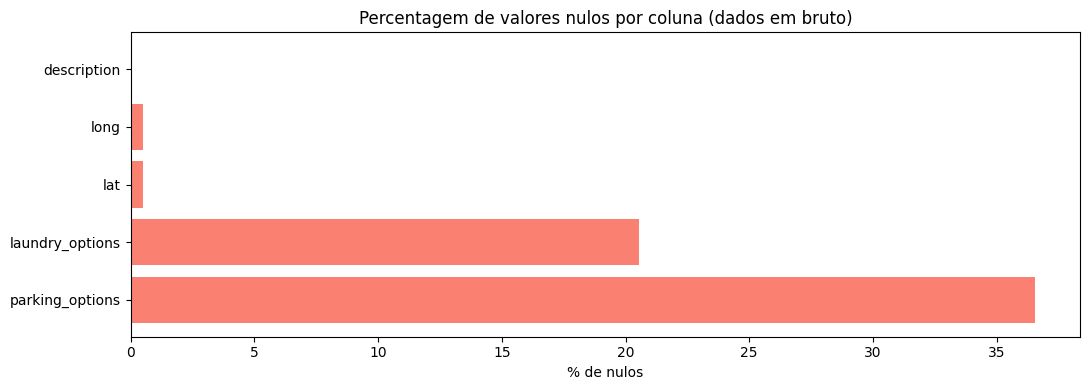

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import col, sum as spark_sum

# ── Gráfico A: Percentagem de nulos por coluna ──────────────────────────────
# Mostra quais colunas têm mais valores em falta antes de qualquer tratamento
total_registos = df.count()

nulos_pct = df.select([
    (spark_sum(col(c).isNull().cast('int')) / total_registos * 100).alias(c)
    for c in df.columns
]).toPandas().T.reset_index()
nulos_pct.columns = ['coluna', 'pct_nulos']
nulos_pct = nulos_pct[nulos_pct['pct_nulos'] > 0].sort_values('pct_nulos', ascending=False)

plt.figure(figsize=(11, 4))
plt.barh(nulos_pct['coluna'], nulos_pct['pct_nulos'], color='salmon')
plt.title('Percentagem de valores nulos por coluna (dados em bruto)')
plt.xlabel('% de nulos')
plt.tight_layout()
plt.show()

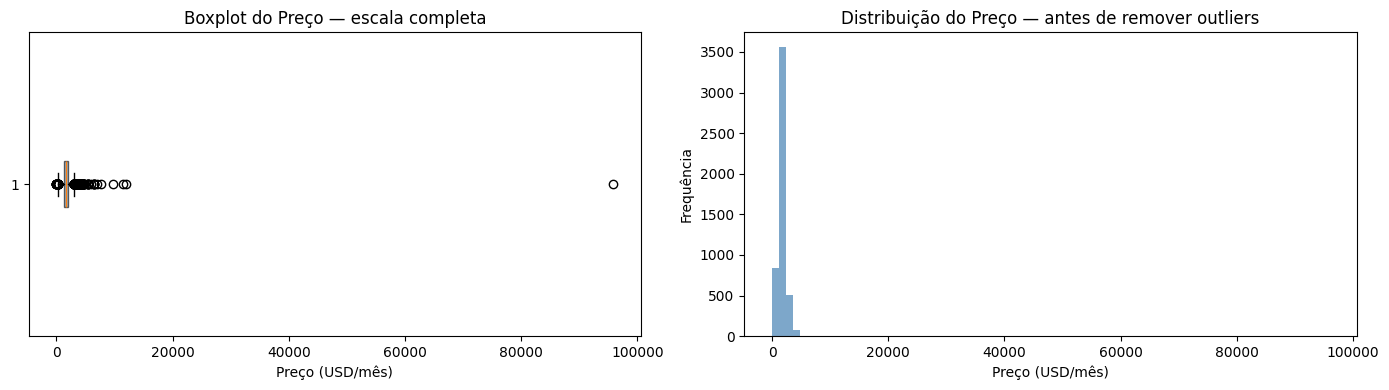

Preço mínimo: 0 USD
Preço máximo: 95,834 USD
Média       : 1,738 USD
Mediana     : 1,600 USD


In [49]:
# ── Gráfico B: Boxplot do preço ANTES da remoção de outliers ───────────────
# Justifica visualmente os filtros aplicados na secção 6
from pyspark.sql.functions import col

df_raw_price = df.select('price').filter(col('price').isNotNull()) \
                 .limit(5000).toPandas()
df_raw_price['price'] = pd.to_numeric(df_raw_price['price'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot completo
axes[0].boxplot(df_raw_price['price'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('Boxplot do Preço — escala completa')
axes[0].set_xlabel('Preço (USD/mês)')

# Histograma em bruto (sem filtro)
axes[1].hist(df_raw_price['price'].dropna(), bins=80, color='steelblue', alpha=0.7)
axes[1].set_title('Distribuição do Preço — antes de remover outliers')
axes[1].set_xlabel('Preço (USD/mês)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()
print(f'Preço mínimo: {df_raw_price["price"].min():,.0f} USD')
print(f'Preço máximo: {df_raw_price["price"].max():,.0f} USD')
print(f'Média       : {df_raw_price["price"].mean():,.0f} USD')
print(f'Mediana     : {df_raw_price["price"].median():,.0f} USD')

## 4. Tratamento de Valores Ausentes

Estratégia:
- Registos com `price` nulo → **remover** (variável alvo)
- Variáveis numéricas → substituir pela **mediana**
- Variáveis categóricas → substituir por `'unknown'`

In [50]:
# Remover registos sem preço
from pyspark.sql.functions import col

df = df.withColumn("price", col("price").cast("double")) #converte todos os valores para númericos, assim mesmo algum valor que esteja em texto é considerado nulo e removido
df = df.dropna(subset=['price'])
print(f'Registos após remoção de price nulos: {df.count():,}')

Registos após remoção de price nulos: 384,977


In [51]:
# Confirmar colunas principais com registos nulos
colunas_verificar = ['price', 'sqfeet', 'beds', 'baths', 'type',
                     'state', 'lat', 'long', 'laundry_options', 'parking_options']

df.select([
    spark_sum(col(c).isNull().cast('int')).alias(c)
    for c in colunas_verificar
]).show()

+-----+------+----+-----+----+-----+----+----+---------------+---------------+
|price|sqfeet|beds|baths|type|state| lat|long|laundry_options|parking_options|
+-----+------+----+-----+----+-----+----+----+---------------+---------------+
|    0|     0|   0|    0|   0|    0|1918|1918|          79026|         140687|
+-----+------+----+-----+----+-----+----+----+---------------+---------------+



In [52]:
# Preencher nulos em colunas de texto com 'unknown'
colunas_texto = ['type', 'laundry_options', 'parking_options', 'state']
df = df.fillna('unknown', subset=colunas_texto)
print('Nulos em colunas de texto preenchidos com unknown.')

Nulos em colunas de texto preenchidos com unknown.


In [53]:
from pyspark.sql.functions import percentile_approx, col

# Mediana para sqfeet
for c in ['sqfeet']:
    mediana = df.select(percentile_approx(c, 0.5)).collect()[0][0]
    if mediana is not None:
        df = df.fillna({c: float(mediana)})
        print(f'  {c}: nulos preenchidos com mediana = {mediana}')
    else:
        print(f'  {c}: mediana indisponível, a ignorar')

# Moda para beds e baths
for c in ['beds', 'baths']:
    moda = df.groupBy(c).count().orderBy('count', ascending=False).first()[0]
    if moda is not None:
        df = df.fillna({c: float(moda)})
        print(f'  {c}: nulos preenchidos com moda = {moda}')
    else:
        print(f'  {c}: moda indisponível, a ignorar')

# Remover registos sem lat ou long
antes = df.count()
df = df.dropna(subset=['lat', 'long'])
depois = df.count()
removidos = antes - depois
print(f'\n  lat/long: {removidos:,} registos removidos ({(removidos/antes*100):.2f}%)')
print(f'  Registos restantes: {depois:,}')

  sqfeet: nulos preenchidos com mediana = 949.0
  beds: nulos preenchidos com moda = 2.0
  baths: nulos preenchidos com moda = 1.0

  lat/long: 1,918 registos removidos (0.50%)
  Registos restantes: 383,059


In [54]:
# Confirmar que não restam nulos nas colunas principais
colunas_verificar = ['price', 'sqfeet', 'beds', 'baths', 'type',
                     'state', 'lat', 'long', 'laundry_options', 'parking_options']

df.select([
    spark_sum(col(c).isNull().cast('int')).alias(c)
    for c in colunas_verificar
]).show()

+-----+------+----+-----+----+-----+---+----+---------------+---------------+
|price|sqfeet|beds|baths|type|state|lat|long|laundry_options|parking_options|
+-----+------+----+-----+----+-----+---+----+---------------+---------------+
|    0|     0|   0|    0|   0|    0|  0|   0|              0|              0|
+-----+------+----+-----+----+-----+---+----+---------------+---------------+



## 5. Remoção de Colunas Irrelevantes

`id`, `url`, `region_url`, `image_url` e `description` são identificadores ou texto livre sem valor preditivo para o modelo.

In [55]:
colunas_a_remover = ['id', 'url', 'region_url', 'image_url', 'description']
colunas_a_remover = [c for c in colunas_a_remover if c in df.columns]

df = df.drop(*colunas_a_remover)

print(f'Removidas  : {colunas_a_remover}')
print(f'Restantes ({len(df.columns)}): {df.columns}')

Removidas  : ['id', 'url', 'region_url', 'image_url', 'description']
Restantes (17): ['region', 'price', 'type', 'sqfeet', 'beds', 'baths', 'cats_allowed', 'dogs_allowed', 'smoking_allowed', 'wheelchair_access', 'electric_vehicle_charge', 'comes_furnished', 'laundry_options', 'parking_options', 'lat', 'long', 'state']


## 6. Tratamento de Outliers

Valores fora de gamas razoáveis são provavelmente erros de inserção e são removidos.

In [56]:
print(f'Registos antes: {df.count():,}')

df = df.filter(
    (col('price')  >= 100)  & (col('price')  <= 10000) &
    (col('sqfeet') >  50)   & (col('sqfeet') <= 10000) &
    (col('beds')   >= 0)    & (col('beds')   <= 10)    &
    (col('baths')  >= 0)    & (col('baths')  <= 10)
)

print(f'Registos depois: {df.count():,}')

Registos antes: 383,059
Registos depois: 379,638


## 7. Codificação de Variáveis Categóricas

Pipeline **StringIndexer → OneHotEncoder** para cada coluna categórica:
- `StringIndexer` → índice numérico por frequência decrescente
- `OneHotEncoder` → vector binário esparso (evita ordem artificial)

Colunas: `type`, `laundry_options`, `parking_options`, `state`

In [57]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

colunas_cat = ['type', 'laundry_options', 'parking_options', 'state']

indexers = [
    StringIndexer(inputCol=c, outputCol=c + '_idx', handleInvalid='keep')
    for c in colunas_cat
]

encoders = [
    OneHotEncoder(inputCol=c + '_idx', outputCol=c + '_ohe')
    for c in colunas_cat
]

pipeline_cat = Pipeline(stages=indexers + encoders)
df = pipeline_cat.fit(df).transform(df)

print('Codificação categórica concluída.')
df.select(['type', 'type_idx', 'type_ohe']).show(10)

Codificação categórica concluída.
+---------+--------+--------------+
|     type|type_idx|      type_ohe|
+---------+--------+--------------+
|apartment|     0.0|(12,[0],[1.0])|
|    condo|     3.0|(12,[3],[1.0])|
|apartment|     0.0|(12,[0],[1.0])|
|apartment|     0.0|(12,[0],[1.0])|
|apartment|     0.0|(12,[0],[1.0])|
|apartment|     0.0|(12,[0],[1.0])|
|apartment|     0.0|(12,[0],[1.0])|
|apartment|     0.0|(12,[0],[1.0])|
|apartment|     0.0|(12,[0],[1.0])|
|    condo|     3.0|(12,[3],[1.0])|
+---------+--------+--------------+
only showing top 10 rows


## 8. Normalização / Padronização de Variáveis Numéricas

**StandardScaler** (z-score): `z = (x - média) / desvio_padrão`  
O **VectorAssembler** agrega as colunas numéricas num vector antes do scaler.

In [58]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType

colunas_num = ['sqfeet', 'beds', 'baths', 'lat', 'long']

for c in colunas_num:
    df = df.withColumn(c, col(c).cast(DoubleType()))

assembler_num = VectorAssembler(
    inputCols=colunas_num,
    outputCol='features_num_raw',
    handleInvalid='skip'
)

scaler = StandardScaler(
    inputCol='features_num_raw',
    outputCol='features_num_scaled',
    withMean=True,
    withStd=True
)

pipeline_num = Pipeline(stages=[assembler_num, scaler])
df = pipeline_num.fit(df).transform(df)

print('Padronização concluída.')
df.select(['features_num_raw', 'features_num_scaled']).show(5, truncate=False)

Padronização concluída.
+---------------------------------+-----------------------------------------------------------------------------------------------------+
|features_num_raw                 |features_num_scaled                                                                                  |
+---------------------------------+-----------------------------------------------------------------------------------------------------+
|[1078.0,3.0,2.0,39.5483,-119.796]|[0.21116202467591008,1.2647903933235896,0.8861875617602377,0.4168262076002595,-1.6394657779552149]   |
|[1001.0,2.0,2.0,39.5026,-119.789]|[0.016128370361887728,0.12344316718850051,0.8861875617602377,0.40858937901157183,-1.6390424454799608]|
|[1683.0,2.0,2.0,39.6269,-119.708]|[1.7435693085718,0.12344316718850051,0.8861875617602377,0.43099283182500603,-1.6341438839805975]     |
|[708.0,1.0,1.0,39.4477,-119.771] |[-0.7260126778719895,-1.0179040589465884,-0.815590562313224,0.39869437048817974,-1.63795387625788]   |
|[250.0,0.

## 9. Visualizações

`.limit(5000).toPandas()` converte uma amostra para Pandas para criar os gráficos.

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_pd = df.select('price', 'sqfeet', 'beds', 'baths', 'type', 'state') \
          .limit(5000) \
          .toPandas()

# Garantir tipos numéricos no Pandas
for c in ['price', 'sqfeet', 'beds', 'baths']:
    df_pd[c] = pd.to_numeric(df_pd[c], errors='coerce')

print(f'Amostra: {df_pd.shape}')
df_pd.head()

Amostra: (5000, 6)


,price,sqfeet,beds,baths,type,state
0,1148.0,1078.0,3.0,2.0,apartment,ca
1,1200.0,1001.0,2.0,2.0,condo,ca
2,1813.0,1683.0,2.0,2.0,apartment,ca
3,1095.0,708.0,1.0,1.0,apartment,ca
4,289.0,250.0,0.0,1.0,apartment,ca


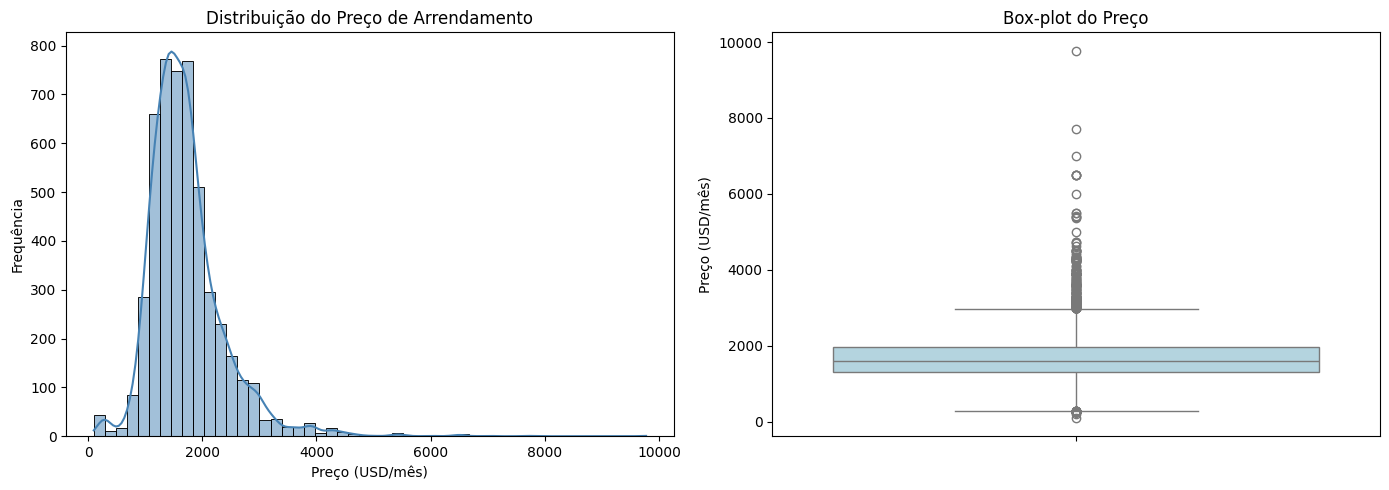

In [60]:
# ── Gráfico 1: Distribuição do Preço ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_pd['price'].dropna(), bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribuição do Preço de Arrendamento')
axes[0].set_xlabel('Preço (USD/mês)')
axes[0].set_ylabel('Frequência')

sns.boxplot(y=df_pd['price'].dropna(), color='lightblue', ax=axes[1])
axes[1].set_title('Box-plot do Preço')
axes[1].set_ylabel('Preço (USD/mês)')

plt.tight_layout()
plt.savefig('grafico_preco.png', dpi=100)
plt.show()

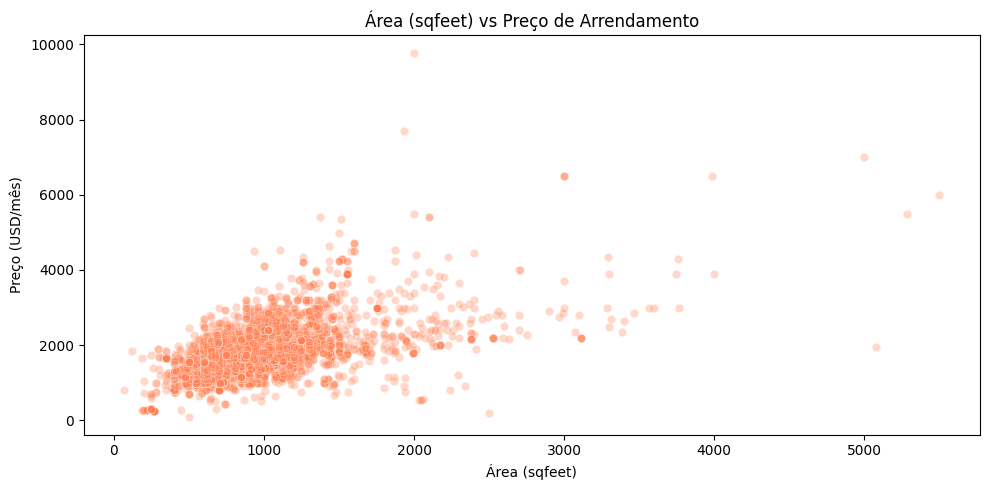

In [61]:
# ── Gráfico 2: Scatter — Área vs Preço ──────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_pd, x='sqfeet', y='price', alpha=0.3, color='coral')
plt.title('Área (sqfeet) vs Preço de Arrendamento')
plt.xlabel('Área (sqfeet)')
plt.ylabel('Preço (USD/mês)')
plt.tight_layout()
plt.savefig('grafico_area_preco.png', dpi=100)
plt.show()

/tmp/ipykernel_4838/3632362734.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=preco_tipo.index, y=preco_tipo.values, palette='Blues_d')


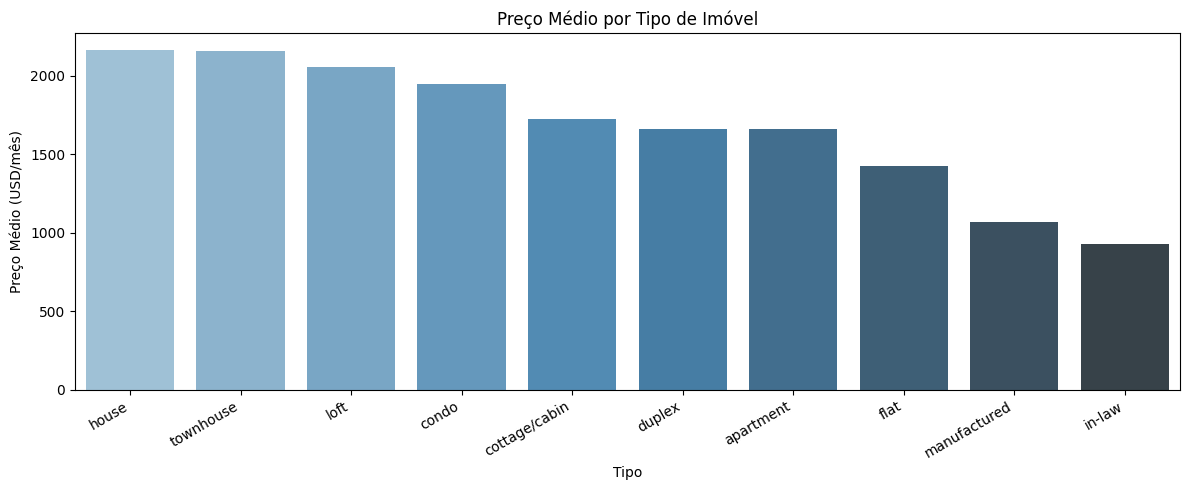

In [62]:
# ── Gráfico 3: Preço Médio por Tipo de Imóvel ───────────────────────────────
preco_tipo = df_pd.groupby('type')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=preco_tipo.index, y=preco_tipo.values, palette='Blues_d')
plt.title('Preço Médio por Tipo de Imóvel')
plt.xlabel('Tipo')
plt.ylabel('Preço Médio (USD/mês)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('grafico_tipo_preco.png', dpi=100)
plt.show()

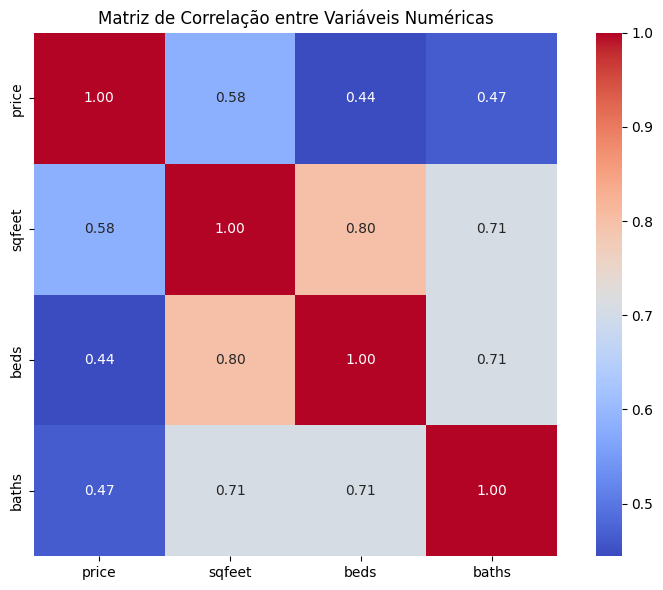

In [63]:
# ── Gráfico 4: Matriz de Correlação ─────────────────────────────────────────
plt.figure(figsize=(8, 6))
corr = df_pd[['price', 'sqfeet', 'beds', 'baths']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.savefig('grafico_correlacao.png', dpi=100)
plt.show()

## 10. Preparação Final do Dataset para ML

Combinamos o vector numérico padronizado com os vectores OHE num único vector `features`.  
A coluna `price` é renomeada para `label` — convenção do Spark MLlib.

In [64]:
from pyspark.ml.feature import VectorAssembler

colunas_ohe = [c + '_ohe' for c in colunas_cat]

assembler_final = VectorAssembler(
    inputCols=['features_num_scaled'] + colunas_ohe,
    outputCol='features',
    handleInvalid='skip'
)

df_final = assembler_final.transform(df)

df_ml = df_final.select(
    col('features'),
    col('price').alias('label')
)

print(f'Dataset final: {df_ml.count():,} registos')
df_ml.show(5, truncate=False)

Dataset final: 379,638 registos
+-------------------------------------------------------------------------------------------------------------------------------------------------+------+
|features                                                                                                                                         |label |
+-------------------------------------------------------------------------------------------------------------------------------------------------+------+
|(82,[0,1,2,3,4,5,17,26,31],[0.21116202467591008,1.2647903933235896,0.8861875617602377,0.4168262076002595,-1.6394657779552149,1.0,1.0,1.0,1.0])   |1148.0|
|(82,[0,1,2,3,4,8,19,26,31],[0.016128370361887728,0.12344316718850051,0.8861875617602377,0.40858937901157183,-1.6390424454799608,1.0,1.0,1.0,1.0])|1200.0|
|(82,[0,1,2,3,4,5,17,25,31],[1.7435693085718,0.12344316718850051,0.8861875617602377,0.43099283182500603,-1.6341438839805975,1.0,1.0,1.0,1.0])     |1813.0|
|(82,[0,1,2,3,4,5,17,26,31],[-0.726012

In [65]:
# Guardar em Parquet para reutilização na Fase 3
df_ml.write.mode('overwrite').parquet('housing_ml_ready.parquet')
print('Dataset guardado em housing_ml_ready.parquet')

Dataset guardado em housing_ml_ready.parquet


In [66]:
print('=' * 58)
print('  RESUMO DA FASE 2')
print('=' * 58)
print(f'  Registos finais             : {df_ml.count():,}')
print(f'  Features numéricas          : {colunas_num}')
print(f'  Features categóricas (OHE)  : {colunas_cat}')
print(f'  Variável alvo               : price  (regressão)')
print(f'  Normalização                : StandardScaler (z-score)')
print(f'  Encoding categórico         : StringIndexer + OHE')
print('=' * 58)

  RESUMO DA FASE 2
  Registos finais             : 379,638
  Features numéricas          : ['sqfeet', 'beds', 'baths', 'lat', 'long']
  Features categóricas (OHE)  : ['type', 'laundry_options', 'parking_options', 'state']
  Variável alvo               : price  (regressão)
  Normalização                : StandardScaler (z-score)
  Encoding categórico         : StringIndexer + OHE


---
# Fase 3: Treino e Avaliação do Modelo

O dataset foi completamente processado na Fase 2 e o vector `features` + coluna `label` (price) estão prontos em `df_ml`. Nesta fase treinamos, avaliamos e comparamos modelos de ML com Spark MLlib.

## 11. Divisão Treino / Teste

Divisão 80/20 com `seed=42` para garantir reprodutibilidade. 80% dos dados são usados para treinar os modelos e 20% para avaliação final.

In [67]:
# Divisão 80% treino / 20% teste
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

print(f'Treino : {train_df.count():,} registos')
print(f'Teste  : {test_df.count():,} registos')

Treino : 303,633 registos
Teste  : 76,005 registos


## 12. Avaliadores de Desempenho

Definidos uma única vez e reutilizados por todos os modelos:
- **RMSE** — penaliza erros grandes; expresso em USD
- **MAE** — erro médio absoluto; mais robusto a outliers
- **R²** — proporção da variância explicada (1.0 = perfeito)

In [68]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_rmse = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='rmse')
evaluator_mae  = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='mae')
evaluator_r2   = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='r2')

print('Avaliadores criados: RMSE, MAE, R²')

Avaliadores criados: RMSE, MAE, R²


## 13. Modelo 1 — Regressão Linear

Modelo base de referência. Assume relação linear entre features e preço. É o modelo mais simples e interpretável, mas pode não capturar relações não-lineares.

Ver: https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.LinearRegression.html

In [69]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol='features',
    labelCol='label',
    maxIter=100,
    regParam=0.1,        # regularização L2 para evitar overfitting
    elasticNetParam=0.0  # 0.0 = Ridge, 1.0 = Lasso
)

lr_model      = lr.fit(train_df)
lr_predictions = lr_model.transform(test_df)

lr_rmse = evaluator_rmse.evaluate(lr_predictions)
lr_mae  = evaluator_mae.evaluate(lr_predictions)
lr_r2   = evaluator_r2.evaluate(lr_predictions)

print(f'Regressão Linear → RMSE: {lr_rmse:.2f} USD | MAE: {lr_mae:.2f} USD | R²: {lr_r2:.4f}')

if lr_r2 >= 0.8:
    print('Interpretação: Ótimo ajuste — o modelo explica bem a variação dos dados.')
elif lr_r2 >= 0.5:
    print('Interpretação: Ajuste razoável — o modelo explica parte da variação, mas pode ser melhorado.')
else:
    print('Interpretação: Ajuste fraco — o modelo não representa bem os dados.')

Regressão Linear → RMSE: 416.75 USD | MAE: 256.23 USD | R²: 0.4959
Interpretação: Ajuste fraco — o modelo não representa bem os dados.


## 14. Modelo 2 — Random Forest

Ensemble de múltiplas árvores de decisão treinadas em paralelo (bagging). Mais robusto que uma única árvore e capaz de capturar relações não-lineares.

Ver: https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.RandomForestRegressor.html

In [70]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol='features',
    labelCol='label',
    numTrees=20,   # número de árvores no ensemble
    maxDepth=5,    # profundidade máxima de cada árvore
    seed=42
)

rf_model      = rf.fit(train_df)
rf_predictions = rf_model.transform(test_df)

rf_rmse = evaluator_rmse.evaluate(rf_predictions)
rf_mae  = evaluator_mae.evaluate(rf_predictions)
rf_r2   = evaluator_r2.evaluate(rf_predictions)

print(f'Random Forest → RMSE: {rf_rmse:.2f} USD | MAE: {rf_mae:.2f} USD | R²: {rf_r2:.4f}')

if rf_r2 >= 0.8:
    print('Interpretação: Ótimo ajuste — o modelo explica bem a variação dos dados.')
elif rf_r2 >= 0.5:
    print('Interpretação: Ajuste razoável — o modelo explica parte da variação, mas pode ser melhorado.')
else:
    print('Interpretação: Ajuste fraco — o modelo não representa bem os dados.')

Random Forest → RMSE: 433.09 USD | MAE: 282.16 USD | R²: 0.4556
Interpretação: Ajuste fraco — o modelo não representa bem os dados.


## 15. Modelo 3 — Gradient Boosted Trees (GBT)

Ensemble sequencial de árvores, onde cada árvore corrige os erros da anterior (boosting). Tipicamente o modelo com melhor desempenho preditivo em dados tabulares estruturados.

Ver: https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.GBTRegressor.html

In [71]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(
    featuresCol='features',
    labelCol='label',
    maxIter=20,    # número de iterações (árvores sequenciais)
    maxDepth=4,    # profundidade máxima de cada árvore
    stepSize=0.1,  # learning rate — controla a contribuição de cada árvore
    seed=42
)

gbt_model      = gbt.fit(train_df)
gbt_predictions = gbt_model.transform(test_df)

gbt_rmse = evaluator_rmse.evaluate(gbt_predictions)
gbt_mae  = evaluator_mae.evaluate(gbt_predictions)
gbt_r2   = evaluator_r2.evaluate(gbt_predictions)

print(f'GBT → RMSE: {gbt_rmse:.2f} USD | MAE: {gbt_mae:.2f} USD | R²: {gbt_r2:.4f}')

if gbt_r2 >= 0.8:
    print('Interpretação: Ótimo ajuste — o modelo explica bem a variação dos dados.')
elif gbt_r2 >= 0.5:
    print('Interpretação: Ajuste razoável — o modelo explica parte da variação, mas pode ser melhorado.')
else:
    print('Interpretação: Ajuste fraco — o modelo não representa bem os dados.')

GBT → RMSE: 398.01 USD | MAE: 253.31 USD | R²: 0.5402
Interpretação: Ajuste razoável — o modelo explica parte da variação, mas pode ser melhorado.


## 16. Comparação dos Modelos

Tabela com as métricas dos três modelos no conjunto de teste.

In [72]:
import pandas as pd

resultados = pd.DataFrame({
    'Modelo'     : ['Regressão Linear', 'Random Forest', 'GBT'],
    'RMSE (USD)' : [round(lr_rmse, 2), round(rf_rmse, 2), round(gbt_rmse, 2)],
    'MAE (USD)'  : [round(lr_mae,  2), round(rf_mae,  2), round(gbt_mae,  2)],
    'R²'         : [round(lr_r2,   4), round(rf_r2,   4), round(gbt_r2,   4)]
})

melhor = resultados.loc[resultados['RMSE (USD)'].idxmin(), 'Modelo']
print(resultados.to_string(index=False))
print(f'\nMelhor modelo (menor RMSE): {melhor}')

          Modelo  RMSE (USD)  MAE (USD)     R²
Regressão Linear      416.75     256.23 0.4959
   Random Forest      433.09     282.16 0.4556
             GBT      398.01     253.31 0.5402

Melhor modelo (menor RMSE): GBT


## 17. Importância das Features

O Random Forest e o GBT calculam automaticamente a importância relativa de cada feature. Como as variáveis categóricas foram codificadas em vetores OHE, agrupamos as suas importâncias por variável original.

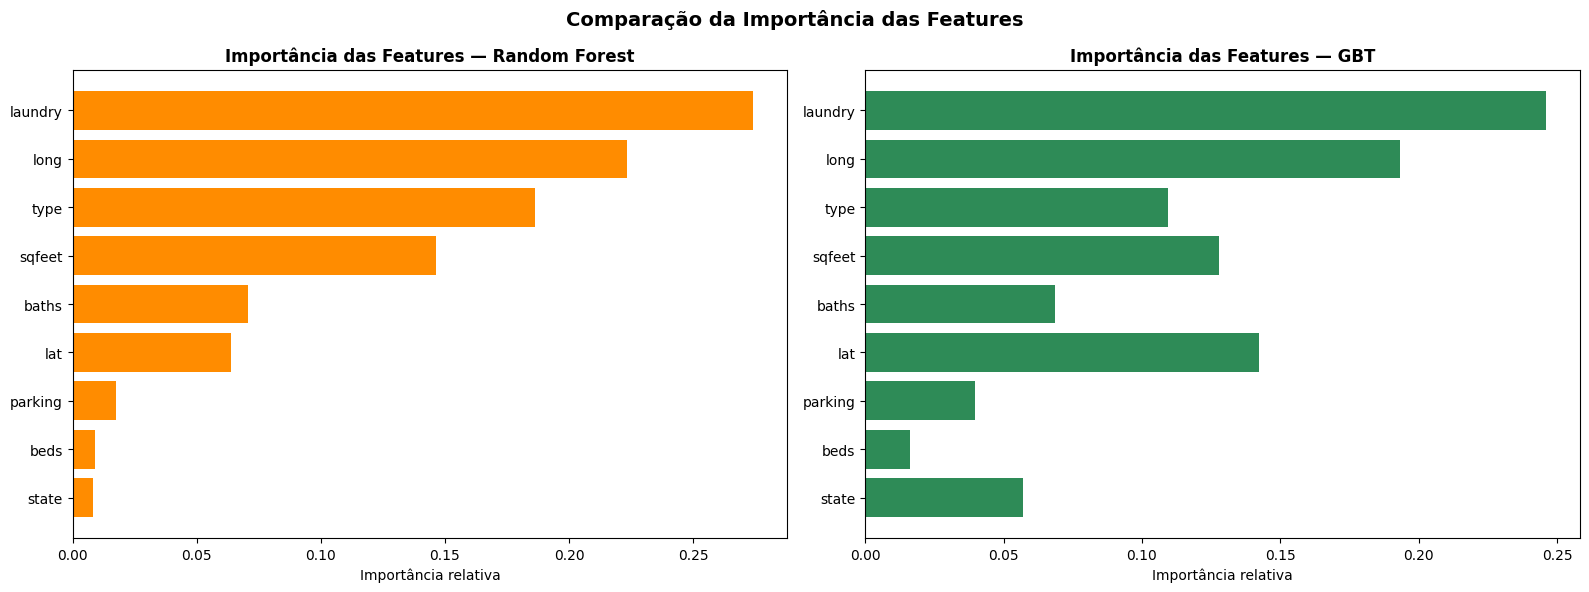

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

imp_rf  = rf_model.featureImportances
imp_gbt = gbt_model.featureImportances

n_total    = rf_model.numFeatures
n_num      = 5   # sqfeet, beds, baths, lat, long
n_ohe      = n_total - n_num
n_por_grupo = n_ohe // 4  # 4 variáveis categóricas

def agrupar(imp):
    vals = [float(imp[i]) for i in range(len(imp))]
    return {
        'sqfeet'  : sum(vals[0:1]),
        'beds'    : sum(vals[1:2]),
        'baths'   : sum(vals[2:3]),
        'lat'     : sum(vals[3:4]),
        'long'    : sum(vals[4:5]),
        'type'    : sum(vals[5                 : 5 +   n_por_grupo]),
        'laundry' : sum(vals[5 +   n_por_grupo : 5 + 2*n_por_grupo]),
        'parking' : sum(vals[5 + 2*n_por_grupo : 5 + 3*n_por_grupo]),
        'state'   : sum(vals[5 + 3*n_por_grupo :]),
    }

df_rf  = pd.DataFrame(list(agrupar(imp_rf).items()),  columns=['Feature', 'Random Forest'])
df_gbt = pd.DataFrame(list(agrupar(imp_gbt).items()), columns=['Feature', 'GBT'])
df_imp = df_rf.merge(df_gbt, on='Feature').sort_values('Random Forest', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(df_imp['Feature'], df_imp['Random Forest'], color='darkorange')
axes[0].set_title('Importância das Features — Random Forest', fontweight='bold')
axes[0].set_xlabel('Importância relativa')
axes[1].barh(df_imp['Feature'], df_imp['GBT'], color='seagreen')
axes[1].set_title('Importância das Features — GBT', fontweight='bold')
axes[1].set_xlabel('Importância relativa')
plt.suptitle('Comparação da Importância das Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_importancia_features.png', dpi=120)
plt.show()

## 18. Exemplos de Previsões — GBT

Exemplos concretos de previsões do melhor modelo face aos valores reais.

In [74]:
print('=== Exemplos de Previsões — GBT ===')
gbt_predictions.select('label', 'prediction') \
    .withColumnRenamed('label',      'Preço Real (USD)') \
    .withColumnRenamed('prediction', 'Preço Previsto (USD)') \
    .show(15)

=== Exemplos de Previsões — GBT ===
+----------------+--------------------+
|Preço Real (USD)|Preço Previsto (USD)|
+----------------+--------------------+
|          2680.0|  1671.2355646870383|
|          1834.0|  1574.8249824301286|
|          1321.0|  1574.8249824301286|
|          2199.0|  1917.5585714720555|
|          1995.0|   1731.580975632079|
|          3655.0|  1863.2813423702514|
|          2230.0|  1780.1958937632119|
|          1239.0|  1238.5550419262593|
|          1239.0|  1238.5550419262593|
|          1239.0|  1238.5550419262593|
|          1239.0|  1238.5550419262593|
|          1239.0|  1238.5550419262593|
|          1239.0|  1238.5550419262593|
|          1239.0|  1238.5550419262593|
|          3409.0|  1911.8962605013846|
+----------------+--------------------+
only showing top 15 rows


## 19. Cross-Validation com Grid Search — GBT

O **Cross-Validation** divide os dados em K folds e treina/avalia o modelo K vezes, dando uma estimativa mais fiável do desempenho real e reduzindo o risco de overfitting. O **ParamGridBuilder** testa diferentes combinações de hiperparâmetros e seleciona a melhor.

Ver: https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.tuning.CrossValidator.html

In [75]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# 2 × 2 = 4 combinações × 3 folds = 12 modelos treinados no total
paramGrid = ParamGridBuilder() \
    .addGrid(gbt.maxDepth, [3, 5]) \
    .addGrid(gbt.maxIter,  [10, 20]) \
    .build()

cv = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_rmse,
    numFolds=3,
    seed=42
)

cv_model         = cv.fit(train_df)
best_gbt         = cv_model.bestModel
best_predictions = best_gbt.transform(test_df)

cv_rmse = evaluator_rmse.evaluate(best_predictions)
cv_mae  = evaluator_mae.evaluate(best_predictions)
cv_r2   = evaluator_r2.evaluate(best_predictions)

print('=== GBT — Cross-Validation com Grid Search (3 folds) ===')
print(f'  Melhor maxDepth : {best_gbt.getMaxDepth()}')
print(f'  Melhor maxIter  : {best_gbt.getMaxIter()}')
print(f'  RMSE (teste)    : {cv_rmse:.2f} USD')
print(f'  MAE  (teste)    : {cv_mae:.2f} USD')
print(f'  R²   (teste)    : {cv_r2:.4f}')

print('\nResultados médios por combinação (RMSE médio no CV):')
for i, params in enumerate(paramGrid):
    print(f'  maxDepth={params[gbt.maxDepth]}, maxIter={params[gbt.maxIter]} → RMSE médio: {cv_model.avgMetrics[i]:.2f} USD')

print(f'\nComparação GBT simples vs GBT com CV:')
print(f'  GBT simples → RMSE: {gbt_rmse:.2f} USD | R²: {gbt_r2:.4f}')
print(f'  GBT com CV  → RMSE: {cv_rmse:.2f} USD | R²: {cv_r2:.4f}')

=== GBT — Cross-Validation com Grid Search (3 folds) ===
  Melhor maxDepth : 5
  Melhor maxIter  : 20
  RMSE (teste)    : 384.80 USD
  MAE  (teste)    : 243.27 USD
  R²   (teste)    : 0.5702

Resultados médios por combinação (RMSE médio no CV):
  maxDepth=3, maxIter=10 → RMSE médio: 434.52 USD
  maxDepth=3, maxIter=20 → RMSE médio: 416.56 USD
  maxDepth=5, maxIter=10 → RMSE médio: 402.72 USD
  maxDepth=5, maxIter=20 → RMSE médio: 386.62 USD

Comparação GBT simples vs GBT com CV:
  GBT simples → RMSE: 398.01 USD | R²: 0.5402
  GBT com CV  → RMSE: 384.80 USD | R²: 0.5702


### 20. Gráficos de Avaliação

Comparação das métricas, valores reais vs previstos, e distribuição dos resíduos.

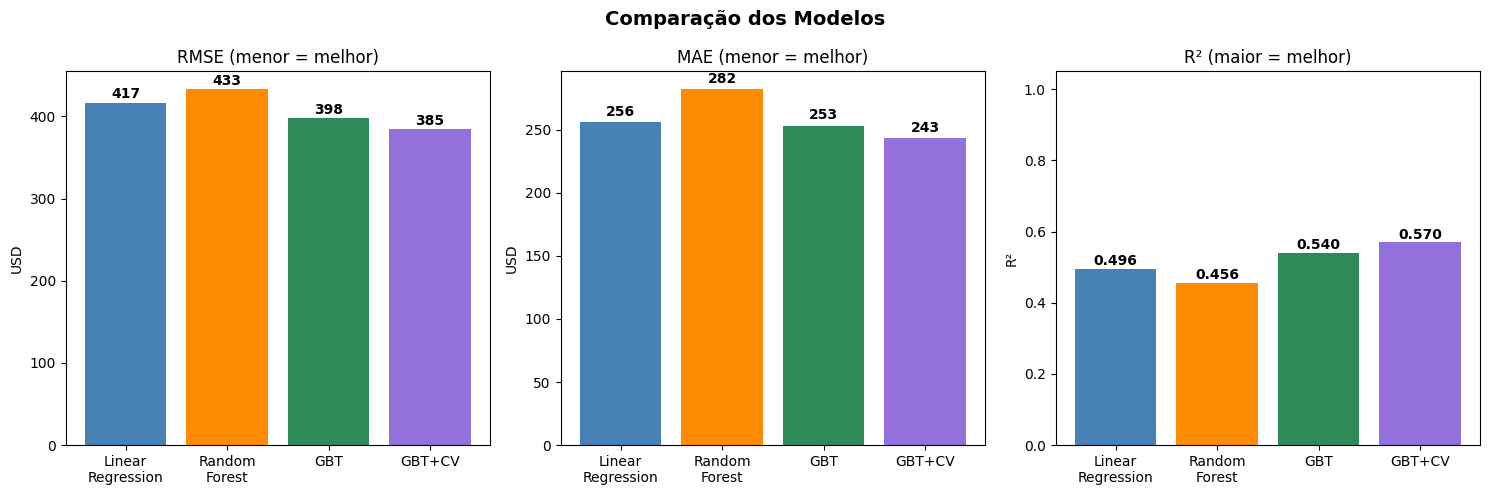

In [76]:
# GRÁFICO 1 — Comparação das métricas
import matplotlib.pyplot as plt

modelos = ['Linear\nRegression', 'Random\nForest', 'GBT', 'GBT+CV']
colors  = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(modelos, [lr_rmse, rf_rmse, gbt_rmse, cv_rmse], color=colors)
axes[0].set_title('RMSE (menor = melhor)'); axes[0].set_ylabel('USD')
for i, v in enumerate([lr_rmse, rf_rmse, gbt_rmse, cv_rmse]):
    axes[0].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

axes[1].bar(modelos, [lr_mae, rf_mae, gbt_mae, cv_mae], color=colors)
axes[1].set_title('MAE (menor = melhor)'); axes[1].set_ylabel('USD')
for i, v in enumerate([lr_mae, rf_mae, gbt_mae, cv_mae]):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

axes[2].bar(modelos, [lr_r2, rf_r2, gbt_r2, cv_r2], color=colors)
axes[2].set_title('R² (maior = melhor)'); axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1.05)
for i, v in enumerate([lr_r2, rf_r2, gbt_r2, cv_r2]):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Comparação dos Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_comparacao_modelos.png', dpi=120)
plt.show()

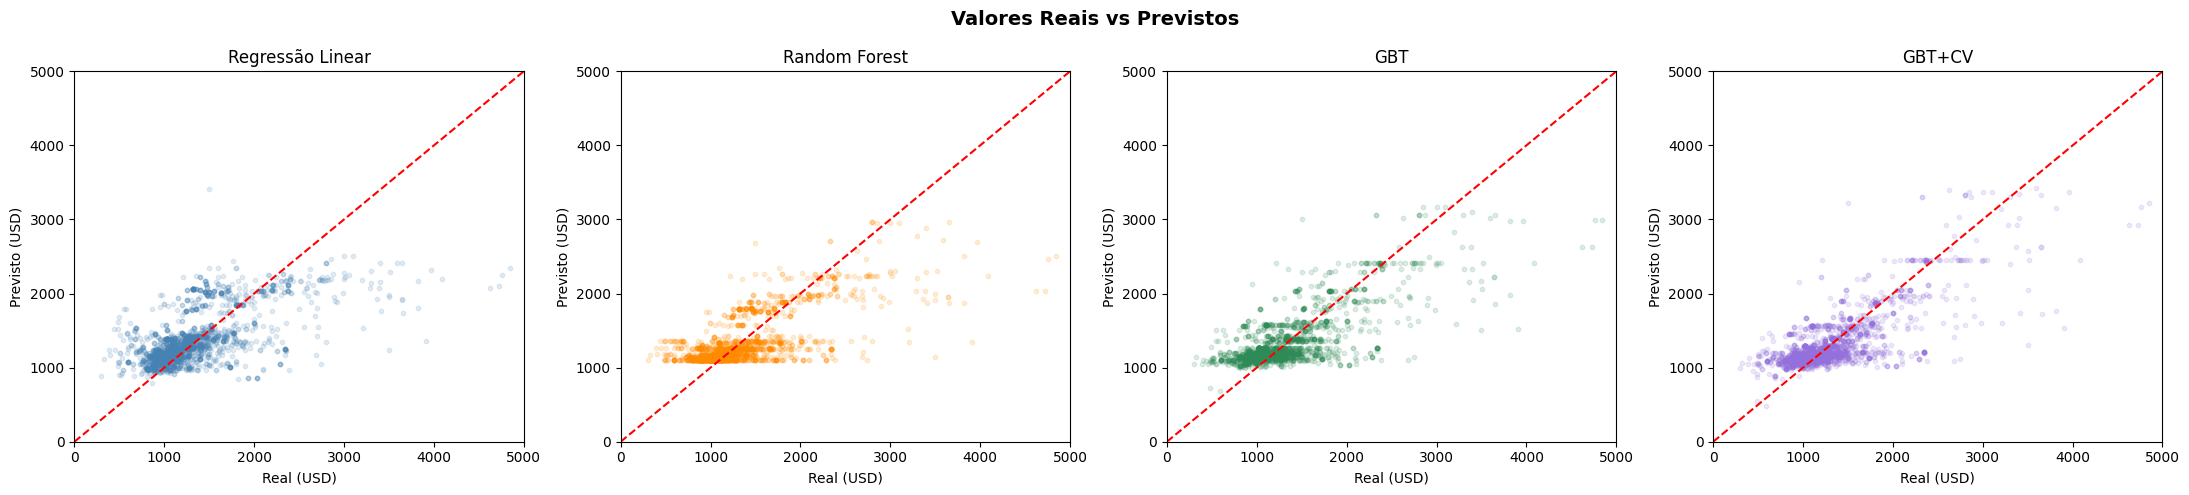

In [77]:
# GRÁFICO 2 — Valores Reais vs Previstos
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, preds, nome, cor in zip(
    axes,
    [lr_predictions, rf_predictions, gbt_predictions, best_predictions],
    ['Regressão Linear', 'Random Forest', 'GBT', 'GBT+CV'],
    ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']
):
    sample = preds.select('label', 'prediction').limit(2000).toPandas()
    ax.scatter(sample['label'], sample['prediction'], alpha=0.15, s=10, color=cor)
    ax.plot([0, 5000], [0, 5000], 'r--', linewidth=1.5)
    ax.set_title(nome); ax.set_xlabel('Real (USD)'); ax.set_ylabel('Previsto (USD)')
    ax.set_xlim(0, 5000); ax.set_ylim(0, 5000)

plt.suptitle('Valores Reais vs Previstos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_real_vs_previsto.png', dpi=120)
plt.show()

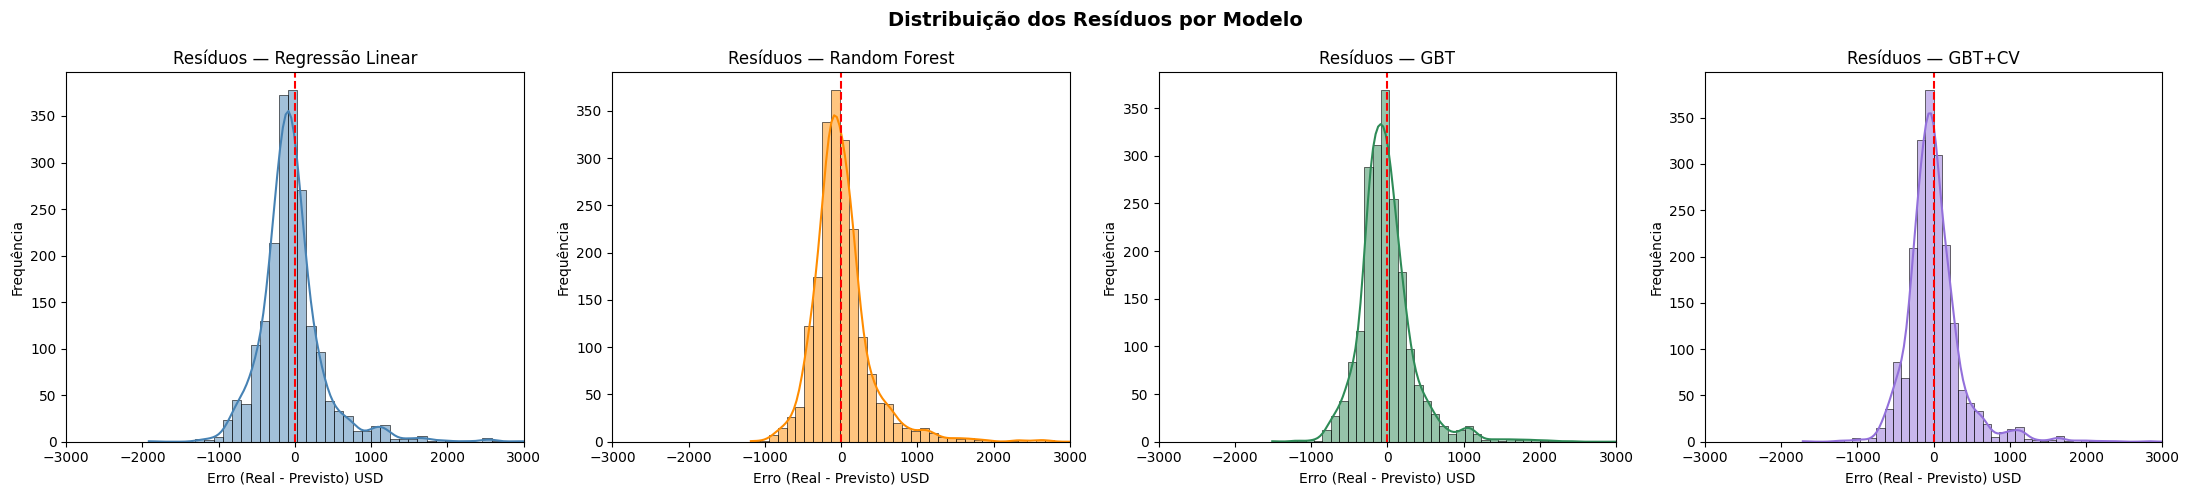

In [78]:
# GRÁFICO 3 — Distribuição dos Resíduos
import seaborn as sns

sample_lr   = lr_predictions.select('label', 'prediction').limit(2000).toPandas()
sample_rf   = rf_predictions.select('label', 'prediction').limit(2000).toPandas()
sample_gbt  = gbt_predictions.select('label', 'prediction').limit(2000).toPandas()
sample_cv   = best_predictions.select('label', 'prediction').limit(2000).toPandas()

for s in [sample_lr, sample_rf, sample_gbt, sample_cv]:
    s['residuo'] = s['label'] - s['prediction']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, sample, nome, cor in zip(
    axes,
    [sample_lr, sample_rf, sample_gbt, sample_cv],
    ['Regressão Linear', 'Random Forest', 'GBT', 'GBT+CV'],
    ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']
):
    sns.histplot(sample['residuo'], bins=60, kde=True, color=cor, ax=ax)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'Resíduos — {nome}', fontsize=12)
    ax.set_xlabel('Erro (Real - Previsto) USD')
    ax.set_ylabel('Frequência')
    ax.set_xlim(-3000, 3000)

plt.suptitle('Distribuição dos Resíduos por Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_residuos.png', dpi=120)
plt.show()

## 21. Métrica Complementar — MAPE

O **MAPE** (Mean Absolute Percentage Error) expressa o erro em percentagem relativamente ao valor real. Independente da escala: um MAPE de 20% significa que o modelo erra em média 20% do preço real.

In [79]:
from pyspark.sql.functions import abs as spark_abs, col

for nome, preds in [
    ('Regressão Linear', lr_predictions),
    ('Random Forest',    rf_predictions),
    ('GBT',             gbt_predictions),
    ('GBT + CV',        best_predictions),
]:
    mape = preds.select(
        (spark_abs(col('label') - col('prediction')) / col('label') * 100).alias('pct_error')
    ).agg({'pct_error': 'mean'}).collect()[0][0]
    print(f'{nome} → MAPE: {mape:.2f}%')

Regressão Linear → MAPE: 23.40%
Random Forest → MAPE: 27.01%
GBT → MAPE: 23.46%
GBT + CV → MAPE: 22.43%


## 22. Resumo Final e Conclusões

Tabela consolidada com todos os modelos.

In [80]:
import pandas as pd

resultados_final = pd.DataFrame({
    'Modelo'     : ['Regressão Linear', 'Random Forest', 'GBT', 'GBT + CV'],
    'RMSE (USD)' : [round(lr_rmse, 2),  round(rf_rmse, 2),  round(gbt_rmse, 2),  round(cv_rmse, 2)],
    'MAE (USD)'  : [round(lr_mae,  2),  round(rf_mae,  2),  round(gbt_mae,  2),  round(cv_mae,  2)],
    'R²'         : [round(lr_r2,   4),  round(rf_r2,   4),  round(gbt_r2,   4),  round(cv_r2,   4)]
})

melhor_final = resultados_final.loc[resultados_final['RMSE (USD)'].idxmin(), 'Modelo']

print('=' * 65)
print('              RESUMO FINAL — FASES 2 e 3')
print('=' * 65)
print(resultados_final.to_string(index=False))
print('=' * 65)
print(f'\nMelhor modelo (menor RMSE): {melhor_final}')

if cv_r2 >= 0.8:
    print('\nConclusão: O GBT com Cross-Validation obteve um ótimo ajuste,')
    print('explicando bem a variação nos preços de arrendamento.')
elif cv_r2 >= 0.5:
    print('\nConclusão: O GBT com Cross-Validation obteve um ajuste razoável.')
    print('O preço de arrendamento é influenciado por factores não presentes')
    print('no dataset (ex: qualidade, proximidade a transportes),')
    print('o que limita o R². Feature engineering adicional poderia melhorar os resultados.')
else:
    print('\nConclusão: Os modelos têm dificuldade em prever com precisão.')
    print('Recomenda-se feature engineering adicional.')

              RESUMO FINAL — FASES 2 e 3
          Modelo  RMSE (USD)  MAE (USD)     R²
Regressão Linear      416.75     256.23 0.4959
   Random Forest      433.09     282.16 0.4556
             GBT      398.01     253.31 0.5402
        GBT + CV      384.80     243.27 0.5702

Melhor modelo (menor RMSE): GBT + CV

Conclusão: O GBT com Cross-Validation obteve um ajuste razoável.
O preço de arrendamento é influenciado por factores não presentes
no dataset (ex: qualidade, proximidade a transportes),
o que limita o R². Feature engineering adicional poderia melhorar os resultados.


## 23. Encerrar a Sessão Spark

In [81]:
spark.stop()
print('Sessão Spark encerrada.')

Sessão Spark encerrada.
